<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Dataset Preview:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc

Decision Tree Results:
Accuracy: 0.869942196531792

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.64      0.73        83
           1       0.00      0.00      0.00        11
           2       0.92      0.98      0.95       235
           3       0.52      1.00      0.68        17

    accuracy                           0.87       346
   macro avg       0.57      0.66      0.59       346
weighted avg       0.85      0.87      0.85       346


Random Forest Results:
Accuracy: 0.9739884393063584

Classification Report:
               precision    recall  f1-score   support

           0       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


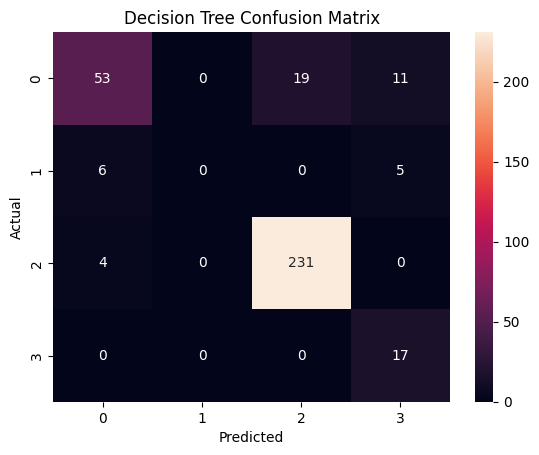

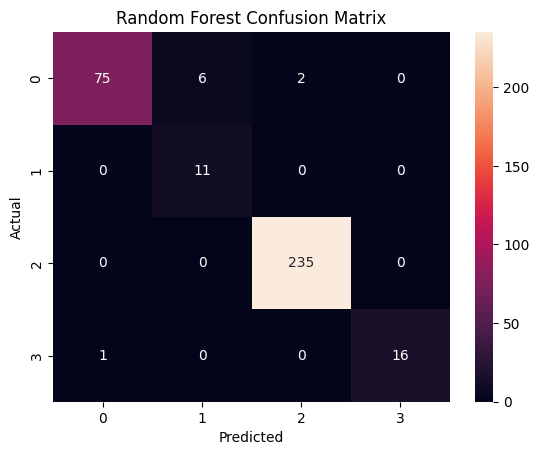

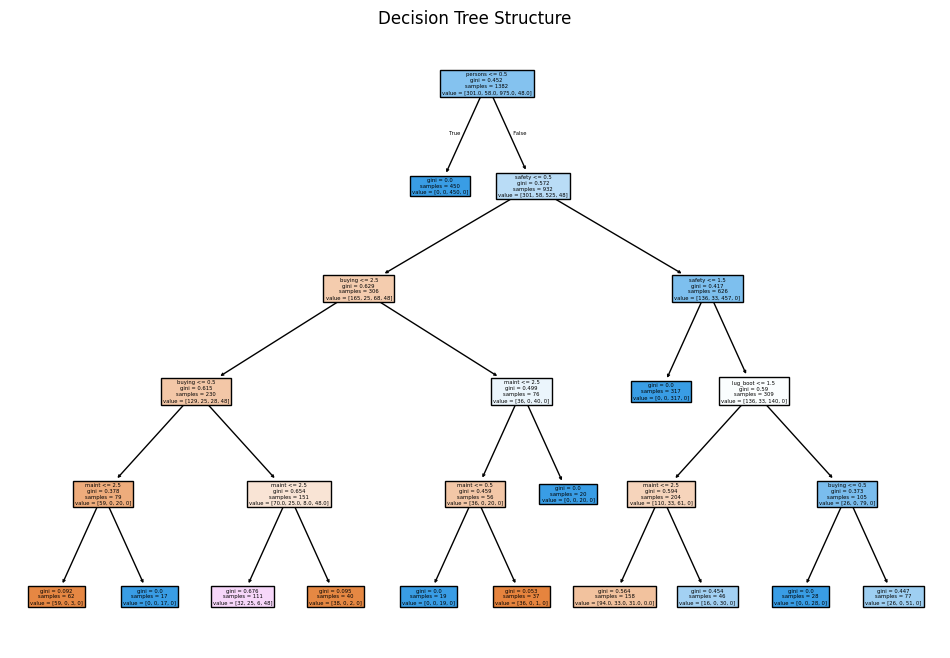

In [2]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2. Load Dataset
# ===============================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv(url, names=columns)

print("Dataset Preview:")
print(df.head())

# ===============================
# 3. Data Preprocessing
# ===============================

# Encode all categorical columns
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('class', axis=1)
y = df['class']

# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. Decision Tree Model
# ===============================
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# ===============================
# 6. Random Forest Model
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# ===============================
# 7. Evaluation Function
# ===============================
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# 8. Evaluate Models
# ===============================
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)

# ===============================
# 9. Confusion Matrix (Separate)
# ===============================

# Decision Tree
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 10. Decision Tree Visualization
# ===============================
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=X.columns)
plt.title("Decision Tree Structure")
plt.show()